In [164]:
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
from zlib import crc32
import matplotlib.pyplot as plt 


### Downloading data

In [165]:
def loading_house_data():
    
    zipFile_path = Path("data/housing.tgz")

    if not zipFile_path.is_file():
        Path("data").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, zipFile_path)
    
    tarfile.open(zipFile_path).extractall(path="data")

    return pd.read_csv(Path("data/housing/housing.csv"))

In [166]:
housing = loading_house_data()

### Information and studying data

In [167]:
housing
# housing.info()
# housing['ocean_proximity'].value_counts()


# # Visualization using matplotlib
# housing.hist(bins=50, figsize=(36,24))
# plt.show()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


### Adding id's for identification

#### id'ing via indexing

In [168]:
# housing_with_id = housing.reset_index()
# housing_with_id.head()

#### id'ing via existing features

In [169]:
# housing_with_id2 = housing['longitude'] * 1000 + housing['latitude']
# housing_with_id2.describe()

### Creating test and training set

#### 1. Hashing

In [170]:
# Function to decide test set using hashing

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2 ** 32

def split_data(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))

    return data.loc[~in_test_set], data.loc[in_test_set]

In [171]:
# train_set, test_set = split_data(housing_with_id, 0.2, "index") 

#### 2. Using sklearn

In [172]:
# train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

### Stratifying the median_income category

In [173]:
housing["income_cat"] = pd.cut(housing["median_income"], bins= [0., 1.5, 3.0, 4.5, 6.0, np.inf], labels= ["less than 15k", "less than 30k", "less than 45k", "less than 60k", "above 60k"])

In [174]:
# housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
# plt.xlabel("Income category")
# plt.ylabel("Number of districts")
# plt.show()

In [175]:
# Splitting of test and training data post stratification

strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify= housing["income_cat"], random_state=42)

# It's an accepted practice to drop the newly formed income category after stratification is done

for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

housing = strat_train_set.copy()

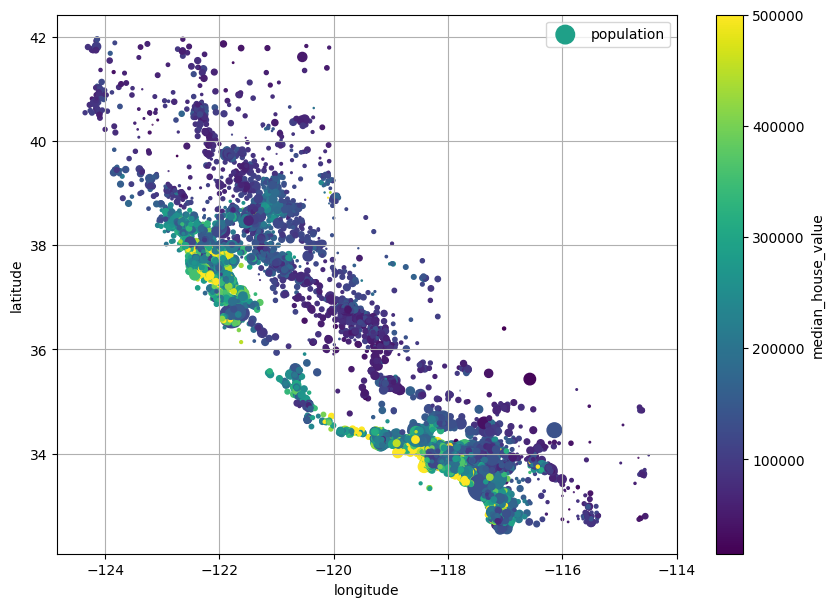

In [176]:
housing.plot(kind="scatter", x='longitude', y='latitude', grid=True, s=housing["population"]/100, label="population", c="median_house_value", colorbar=True, legend=True, figsize=(10,7))

plt.show()

In [177]:
corr_matrix = housing.corr(numeric_only=True)

In [178]:
corr_matrix["median_house_value"].sort_values(ascending= False)

median_house_value    1.000000
median_income         0.686907
total_rooms           0.131320
housing_median_age    0.109677
households            0.062113
total_bedrooms        0.046629
population           -0.026792
longitude            -0.044139
latitude             -0.143810
Name: median_house_value, dtype: float64

By using the correlation matrix, we can find out different correlations between median house value and other attributes. The top attributes are analyzed inorder to find reasonable relations to use in designing the model.

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

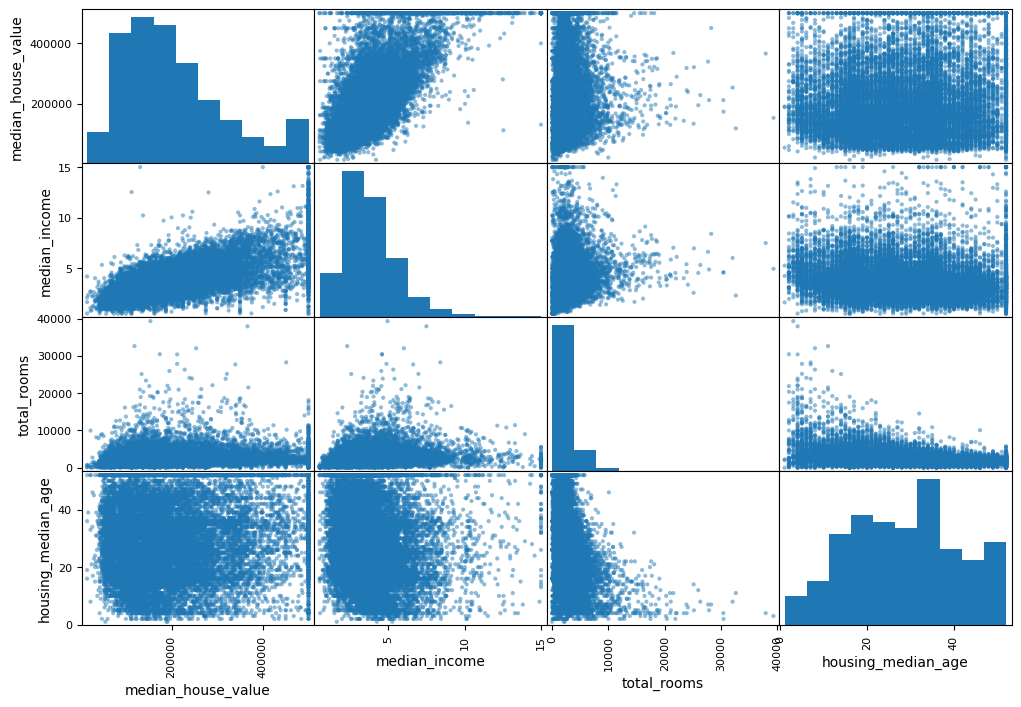

In [179]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]

scatter_matrix(housing[attributes], figsize=(12,8))

The above scatter plots indicate a strong relation between median house value and median income which can become the starting point of the project and model

<Axes: xlabel='median_income', ylabel='median_house_value'>

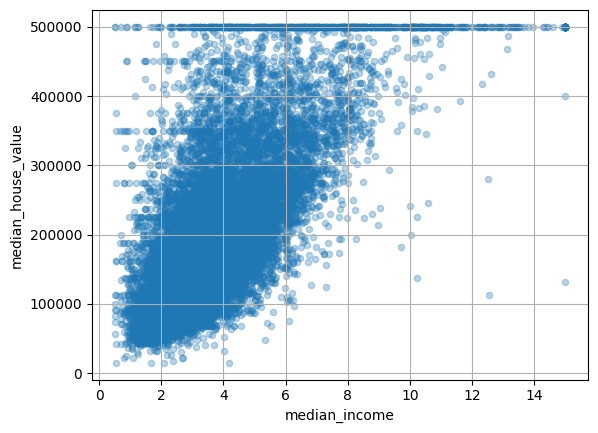

In [180]:
housing.plot(kind="scatter", y="median_house_value", x= "median_income", alpha= 0.3, grid= True)

### Feature engineered that have better correlation with median house value

In [181]:
housing["population per household*"] = housing["population"] / housing["households"]
housing["Rooms per household*"] = housing["total_rooms"] / housing["households"]
housing["bedrooms to rooms ratio*"] = housing["total_bedrooms"] / housing["total_rooms"]

In [182]:
corr_matrix = housing.corr(numeric_only=True)

In [183]:
corr_matrix["median_house_value"].sort_values(ascending= False)

median_house_value           1.000000
median_income                0.686907
Rooms per household*         0.159235
total_rooms                  0.131320
housing_median_age           0.109677
households                   0.062113
total_bedrooms               0.046629
population per household*   -0.026640
population                  -0.026792
longitude                   -0.044139
latitude                    -0.143810
bedrooms to rooms ratio*    -0.253449
Name: median_house_value, dtype: float64

# Preparing data for cleaning and use

In [184]:
# Creating a fresh copy to work with

housing_features = strat_train_set.drop("median_house_value", axis=1) # drops median house values as labels seperately
housing_labels = strat_train_set["median_house_value"].copy() # Will use the labels as target values later


### Dealing with missing data and encoding categorical data

In [185]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

housing_num = housing_features.select_dtypes(include=[np.number]) # Excludes ocean_proximity as it's a non numerical datatype and imputer cannot be used
imputer.fit(housing_num)

X = imputer.transform(housing_num) # returns a numpy array

housing_num_tr = pd.DataFrame(X, columns = housing_num.columns, index = housing_num.index) # converts the numpy array into a dataframe


In [186]:
from sklearn.preprocessing import OneHotEncoder

housing_cat = housing_features[["ocean_proximity"]]

housing_cat.head(8)

cat_encoder = OneHotEncoder(sparse_output=False) # avoids getting a sparse matrix

X = cat_encoder.fit_transform(housing_cat)

housing_cat_tr = pd.DataFrame(X, columns=cat_encoder.get_feature_names_out(), index=housing_cat.index)

## Feature Scaling

In [187]:
# housing_features.hist(bins=50, figsize=(12,8)) 
# Used to check which features have a heavy tail so that they can be adjusted and scaled

In [204]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(), transformer=StandardScaler())

model.fit(housing[["median_income"]], housing_labels)

some_new_data = housing[["median_income"]].iloc[:5] # Chooses the first five values to test out as we haven't completed the model yet
predictions = model.predict(some_new_data)

## Custom Transformers

In [1]:
## Good idea to know how to create your own transformations based on the data given. 
## For example it's often useful to find the log of the given attribute that has a heavy tail 

